# Re-evaluation summary

Collects the results written by `reeval_random_forest`, `reeval_svm`, `reeval_lstm` and `reeval_cnn_2d` (`results/reeval/*.json`). Run those first.

**Evaluation protocol (shared by every `reeval_*` notebook, see `src/reeval_common.py`):**

- Data: `data/keypoint_sequences.csv`, 41 Kinect recordings that survived; the larger folder the thesis notebooks used is lost.
- 6 classes, as in the thesis models: `squat_front` and `squat_side` are merged into `squat`.
- Stratified 5-fold cross-validation over **recordings**, repeated with 3 shuffles (15 splits). All windows of a recording are on the same side of every split.
- Nothing from a test fold is used for training, hyperparameter search or early stopping.
- Reported per split: window accuracy, macro F1, accuracy after a majority vote per recording (what the real-time system does), and a majority-class baseline.
- The spread across splits is shown as ± one standard deviation. Splits share recordings, so this understates the true uncertainty; with 41 recordings, differences of a few points are not meaningful.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "keypoint_sequences.csv").exists())
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import reeval_common as rc

results = rc.load_results()
order = ["lstm", "cnn_2d", "random_forest", "svm_b_frames_recording_split", "svm_c_windows_recording_split", "svm_a_frames_random_split"]
rc.summary_table([results[k] for k in order if k in results])

,model,variant,split,samples,splits run,accuracy,macro F1,recording vote,majority baseline
0,LSTM,windows,recording-level 5-fold × 3,121,15,77.3% ± 10.9%,77.6% ± 9.3%,77.3% ± 8.9%,27.1%
1,2D CNN,windows,recording-level 5-fold × 3,121,15,71.0% ± 11.2%,68.3% ± 10.8%,74.4% ± 14.1%,27.1%
2,Random Forest,windows,recording-level 5-fold × 3,121,15,61.2% ± 7.9%,55.8% ± 9.2%,66.9% ± 14.5%,27.1%
3,SVM,B: single frames,recording-level 5-fold × 3,3114,15,58.7% ± 11.4%,55.2% ± 10.8%,63.7% ± 16.6%,26.7%
4,SVM,C: windows,recording-level 5-fold × 3,121,15,38.4% ± 5.1%,19.3% ± 2.8%,37.2% ± 7.4%,27.1%
5,SVM,A: single frames,random frame split 80/20 × 3 (leaky),3114,3,97.6% ± 0.8%,97.4% ± 0.9%,99.2% ± 1.4%,27.2%


## Thesis numbers next to the re-evaluation

In [2]:
thesis_key = {"lstm": "LSTM", "random_forest": "Random Forest", "cnn_2d": "2D CNN", "svm_a_frames_random_split": "SVM"}
rows = []
for key in order:
    if key not in results:
        continue
    r = results[key]
    rows.append({
        "model": r["model"],
        "variant": r["variant"],
        "thesis (one split, lost data)": f"{rc.THESIS_RESULTS[thesis_key[key]]:.1%}" if key in thesis_key else "",
        "re-evaluation accuracy": f"{r['summary']['accuracy_mean']:.1%} ± {r['summary']['accuracy_std']:.1%}",
        "split": r["split"],
    })
pd.DataFrame(rows)

,model,variant,"thesis (one split, lost data)",re-evaluation accuracy,split
0,LSTM,windows,92.5%,77.3% ± 10.9%,recording-level 5-fold × 3
1,2D CNN,windows,68.7%,71.0% ± 11.2%,recording-level 5-fold × 3
2,Random Forest,windows,88.1%,61.2% ± 7.9%,recording-level 5-fold × 3
3,SVM,B: single frames,,58.7% ± 11.4%,recording-level 5-fold × 3
4,SVM,C: windows,,38.4% ± 5.1%,recording-level 5-fold × 3
5,SVM,A: single frames,96.0%,97.6% ± 0.8%,random frame split 80/20 × 3 (leaky)


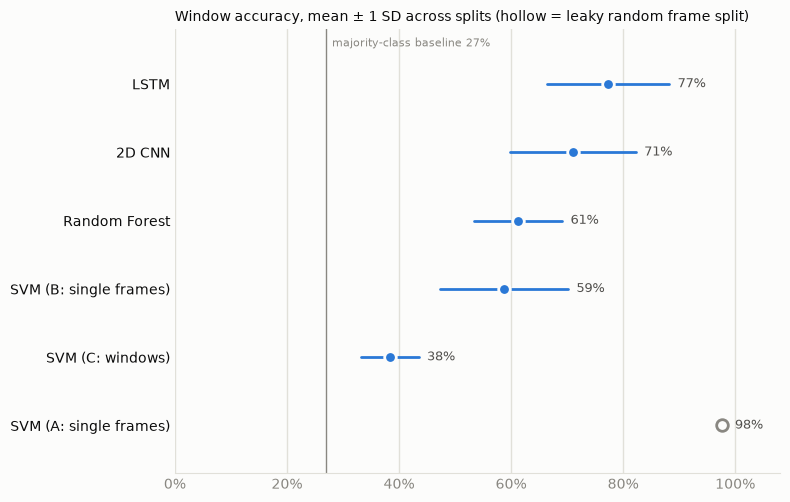

In [3]:
labels, means, stds = [], [], []
for key in order:
    if key not in results:
        continue
    r = results[key]
    labels.append(f"{r['model']} ({r['variant']})" if r["model"] == "SVM" else r["model"])
    means.append(r["summary"]["accuracy_mean"])
    stds.append(r["summary"]["accuracy_std"])
baseline = np.mean([results[k]["summary"]["baseline_accuracy_mean"] for k in order if k in results and "recording" in results[k]["split"]])
leaky = [("random frame split" in results[k]["split"]) for k in order if k in results]

fig, ax = plt.subplots(figsize=(8, 0.62 * len(labels) + 1.4), facecolor=rc.SURFACE)
ypos = np.arange(len(labels))[::-1]
for yy, m, s, is_leaky in zip(ypos, means, stds, leaky):
    color = rc.INK_MUTED if is_leaky else rc.ACCENT
    ax.plot([m - s, m + s], [yy, yy], color=color, linewidth=2, solid_capstyle="round", zorder=2)
    ax.scatter([m], [yy], s=70, color=rc.SURFACE if is_leaky else color, edgecolors=color if is_leaky else rc.SURFACE,
               linewidths=2, zorder=3)
    ax.text(min(m + s, 1.0) + 0.015, yy, f"{m:.0%}", va="center", fontsize=9, color=rc.INK_SECONDARY)
ax.axvline(baseline, color=rc.INK_MUTED, linewidth=1, zorder=1)
ax.text(baseline + 0.01, ypos[0] + 0.55, f"majority-class baseline {baseline:.0%}", fontsize=8, color=rc.INK_MUTED)
ax.set_yticks(ypos, labels)
ax.set_xlim(0, 1.08)
ax.set_ylim(-0.7, len(labels) - 0.2)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}" if v <= 1 else ""))
ax.grid(axis="x", color=rc.GRID, linewidth=1)
ax.set_axisbelow(True)
rc._style(ax)
ax.tick_params(axis="y", colors=rc.INK)
ax.set_title("Window accuracy, mean ± 1 SD across splits (hollow = leaky random frame split)", loc="left", color=rc.INK, fontsize=10)
fig.tight_layout()
fig.savefig(rc.RESULTS_DIR / "model_comparison.png", dpi=160, facecolor=rc.SURFACE)

## Findings (run of 2026-09-11)

1. **The 96% came from the split, not the model.** SVM variant A repeats the original protocol on the 41 recordings and scores 97.6%. The same model with the same features drops to 58.7% ± 11.4% once the test recordings are unseen (variant B).
2. **The LSTM is still the best model:** 77.3% ± 10.9% window accuracy against a 27% majority-class baseline. It beat Random Forest in 13 of the 15 identical splits (mean +16 points). Its lead over the 2D CNN (71.0% ± 11.2%) is smaller: better in 10 of 15 splits, with 2 ties. With 41 recordings that gap is not a reliable difference.
3. **The ranking below the LSTM changed.** In the thesis Random Forest (88.1%) beat the 2D CNN (68.7%). Here the CNN (71.0%) is ahead of Random Forest (61.2% ± 7.9%).
4. **The SVM on windows (variant C) collapses to 38.4%.** It predicts mostly `biceps` for upper-body and `squat` for lower-body exercises. A likely cause: undetected joints are stored as (0, 0), so 45% of the windows contain jumps above 100 px while the median displacement is 2.5 px. After standardisation these spikes dominate the RBF distances; Random Forest is less sensitive to them. Handling missing joints is the first thing to fix before tuning any model further.
5. **Per class,** the LSTM recognises biceps curls, lateral raises and shoulder presses almost perfectly. Bent-over rows, RDLs and squats get confused with each other.
6. **Every number is lower than in the thesis.** This run has only the 41 surviving Kinect recordings (121 windows). The thesis models used a larger folder that also held Kaggle clips, with a single split whose test set was also used for validation. The two sets of numbers do not measure the same thing, and only these can be reproduced from this repository.

## Limitations

- Subject IDs were never stored, so recordings of the same person can be on both sides of a split. The scores measure recognition on new recordings, not on new people.
- 41 recordings and 121 windows: accuracy varies a lot between splits (LSTM 58–92%, 2D CNN 40–83%).
- Features are kept exactly as in the thesis. Missing joints and body scale are not handled.